# Projeto completo — classificação da informalidade na Paraíba

**Integrantes:** Bruno Marque e Vitória Emanuele  
**Disciplina:** Aprendizagem de Máquina — UFPB, 2026.1  
**Fonte:** PNAD Contínua Trimestral, IBGE — quatro trimestres de 2024.  
**Pergunta:** características demográficas, educacionais e ocupacionais permitem classificar uma entrevista como trabalho formal (`0`) ou informal (`1`)?

O roteiro segue: tratamento, construção de `X` e `y`, identificação de `N` e `p`, teste intocado, normalização, dimensão VC e Regra de Ouro, batch/épocas, L2, `E_in`/`E_out`, overfitting, árvore pura, poda por Minimal Cost-Complexity com validação cruzada, Random Forest e escolha do modelo sem usar o teste para ajuste.

Todas as entrevistas são preservadas para captar mudanças ocupacionais. Cada entrevista pesa `1/n`, de modo que cada pessoa contribua com peso total igual a 1. Pessoas e domicílios permanecem integralmente no treino ou no teste.

## 1. Dataset, aplicabilidade e tratamento básico

### 1.1 Fonte, população, alvo e unidade de análise

Cada linha é uma entrevista pessoa-trimestre. Repetições são intencionais: uma pessoa pode mudar de ocupação ou de formalidade. Para impedir que participantes frequentes dominem o modelo, cada entrevista recebe peso inversamente proporcional ao número de aparições da pessoa.

A chave domiciliar é `UPA + V1008 + V1014`; a chave da pessoa acrescenta `V2003`. Todas as entrevistas de um domicílio permanecem no mesmo conjunto. Ano, trimestre, identificadores, frequência e pesos não entram em `X`.

O rótulo segue os grupos do indicador de informalidade do IBGE. Variáveis sobre carteira, CNPJ e posição que definem diretamente o alvo são excluídas. O problema continua sendo classificação de entrevistas, não previsão do próximo período.

### 1.2 Dicionário resumido

- `capital`: reside na capital;
- `situacao_urbana_rural` e `tipo_area`: características geográficas;
- `sexo`, `idade` e `cor_raca`: características demográficas;
- `nivel_instrucao`: escolaridade;
- `numero_trabalhos`: número de trabalhos na semana de referência;
- `grupo_atividade`: setor da atividade principal;
- `grupo_ocupacao`: grupo ocupacional;
- `rendimento_habitual`: rendimento habitual do trabalho principal;
- `horas_habituais`: horas normalmente trabalhadas;
- `target_informal`: 0 formal; 1 informal.

`peso_amostral` é preservado somente para conferir a proporção populacional e não é usado como atributo.
- `id_pessoa`: usado exclusivamente para auditar a deduplicação;
- `id_domicilio`: usado exclusivamente para impedir vazamento entre treino e teste;
- `trimestre_num`: usado para escolher a primeira entrevista e auditar cobertura, não entra no modelo.

### 1.3 Importações e configurações

In [1]:
from pathlib import Path
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.regularizers import l2

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
CAMINHO = Path('dados/pnad/pnad_paraiba_2024.csv')
from sklearn.metrics import log_loss

### 1.4 Carregamento e prévia

In [3]:
df = pd.read_csv(CAMINHO)
print('Formato:', df.shape)
display(df.head())
assert df['target_informal'].nunique() == 2
assert len(df) == 19_550
assert df['id_pessoa'].nunique() == 9_166
pesos_totais = df.groupby('id_pessoa')['peso_pessoa'].sum()
assert np.allclose(pesos_totais, 1.0)
print('Entrevistas:', len(df), '| pessoas:', df['id_pessoa'].nunique(),
      '| domicílios:', df['id_domicilio'].nunique())
display(df.groupby('id_pessoa').size().value_counts().sort_index().to_frame('pessoas'))

N_LINHAS = len(df)
N_PESSOAS = df['id_pessoa'].nunique()
print('N bruto (entrevistas):', N_LINHAS)
print('N efetivo (pessoas com peso total 1):', N_PESSOAS)
print('Colunas brutas:', df.shape[1])

Formato: (19550, 20)


,id_domicilio,id_pessoa,trimestre_num,numero_entrevistas_pessoa,peso_pessoa,capital,situacao_urbana_rural,tipo_area,peso_amostral,sexo,idade,cor_raca,nivel_instrucao,numero_trabalhos,area_trabalho,grupo_atividade,grupo_ocupacao,rendimento_habitual,horas_habituais,target_informal
0,250000680-04-11,250000680-04-11-03,1,3,0.333333,0,2,4,466.198178,1,29,4,5,1,3.0,9,3,2640.0,40,0
1,250000680-05-11,250000680-05-11-01,1,3,0.333333,0,2,4,488.842685,1,39,1,3,1,NaN,3,9,300.0,40,1
2,250000680-05-11,250000680-05-11-02,1,3,0.333333,0,2,4,488.842685,2,33,1,7,1,3.0,9,2,2800.0,30,0
3,250000680-10-11,250000680-10-11-02,1,3,0.333333,0,2,4,434.341454,1,38,4,2,1,NaN,1,6,800.0,44,1
4,250000680-11-11,250000680-11-11-02,1,3,0.333333,0,2,4,500.403536,1,32,4,5,1,NaN,1,9,300.0,44,1


Entrevistas: 19550 | pessoas: 9166 | domicílios: 5737


,pessoas
1,3396
2,2524
3,1878
4,1368


N bruto (entrevistas): 19550
N efetivo (pessoas com peso total 1): 9166
Colunas brutas: 20


### 1.5 Qualidade e balanceamento

In [4]:
qualidade = pd.DataFrame({
    'tipo': df.dtypes.astype(str), 'ausentes': df.isna().sum(),
    'ausentes_%': (df.isna().mean() * 100).round(2), 'unicos': df.nunique()
})
display(qualidade)
taxa_linhas = df['target_informal'].mean()
taxa_pessoas = np.average(df['target_informal'], weights=df['peso_pessoa'])
print('Informalidade por entrevista:', f'{taxa_linhas:.2%}')
print('Informalidade com cada pessoa valendo 1:', f'{taxa_pessoas:.2%}')
assert np.allclose(df.groupby('id_pessoa')['peso_pessoa'].sum(), 1.0)

,tipo,ausentes,ausentes_%,unicos
id_domicilio,str,0,0.00,5737
id_pessoa,str,0,0.00,9166
trimestre_num,int64,0,0.00,4
numero_entrevistas_pessoa,int64,0,0.00,4
peso_pessoa,float64,0,0.00,4
capital,int64,0,0.00,2
situacao_urbana_rural,int64,0,0.00,2
tipo_area,int64,0,0.00,3
peso_amostral,float64,0,0.00,12825
sexo,int64,0,0.00,2


Informalidade por entrevista: 52.09%
Informalidade com cada pessoa valendo 1: 55.61%


## 2. Construção de X e y, engenharia e seleção de atributos

### 2.1 Remoção de colunas inadequadas



In [5]:
COLUNAS_NUMERICAS = ['idade', 'numero_trabalhos', 'rendimento_habitual', 'horas_habituais']
COLUNAS_CATEGORICAS = ['capital', 'situacao_urbana_rural', 'tipo_area', 'sexo', 'cor_raca',
                       'nivel_instrucao', 'grupo_atividade', 'grupo_ocupacao']
COLUNAS_X = COLUNAS_NUMERICAS + COLUNAS_CATEGORICAS
X = df[COLUNAS_X].copy()
y = df['target_informal'].astype(int).copy()
grupos = df['id_domicilio'].copy()
ids_pessoa = df['id_pessoa'].copy()
pesos = df['peso_pessoa'].astype(float).copy()
print('Entradas:', X.shape, '| pessoas únicas:', ids_pessoa.nunique())
assert not {'peso_pessoa', 'numero_entrevistas_pessoa', 'peso_amostral', 'target_informal',
            'id_pessoa', 'id_domicilio', 'trimestre_num'}.intersection(X.columns)

N = len(X)
p_original = X.shape[1]
print('N de entrevistas em X:', N)
print('p antes do one-hot:', p_original)

Entradas: (19550, 12) | pessoas únicas: 9166
N de entrevistas em X: 19550
p antes do one-hot: 12


## 3. Separação treino/teste e pré-processamento

In [6]:
divisor = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
indice_treino, indice_teste = next(divisor.split(X, y, groups=grupos))
X_train = X.iloc[indice_treino].reset_index(drop=True)
X_test = X.iloc[indice_teste].reset_index(drop=True)
y_train = y.iloc[indice_treino].reset_index(drop=True)
y_test = y.iloc[indice_teste].reset_index(drop=True)
grupos_train = grupos.iloc[indice_treino].reset_index(drop=True)
grupos_test = grupos.iloc[indice_teste].reset_index(drop=True)
ids_train = ids_pessoa.iloc[indice_treino].reset_index(drop=True)
ids_test = ids_pessoa.iloc[indice_teste].reset_index(drop=True)
pesos_train = pesos.iloc[indice_treino].reset_index(drop=True)
pesos_test = pesos.iloc[indice_teste].reset_index(drop=True)
print('Treino:', X_train.shape, '| Teste:', X_test.shape)
print('Pessoas treino:', ids_train.nunique(), '| teste:', ids_test.nunique())
print('Domicílios treino:', grupos_train.nunique(), '| teste:', grupos_test.nunique())
print('Pessoas compartilhadas:', len(set(ids_train) & set(ids_test)))
print('Domicílios compartilhados:', len(set(grupos_train) & set(grupos_test)))
assert not (set(ids_train) & set(ids_test))
assert not (set(grupos_train) & set(grupos_test))

print('Peso efetivo treino:', pesos_train.sum())
print('Peso efetivo teste:', pesos_test.sum())

Treino: (15638, 12) | Teste: (3912, 12)
Pessoas treino: 7346 | teste: 1820
Domicílios treino: 4584 | teste: 1153
Pessoas compartilhadas: 0
Domicílios compartilhados: 0
Peso efetivo treino: 7345.999999999999
Peso efetivo teste: 1820.0


### 3.1 Imputação, codificação e padronização sem vazamento



In [ ]:
pipeline_numerico = Pipeline([
    ('imputador', SimpleImputer(strategy='median')),
    ('normalizador', StandardScaler()),
])
pipeline_categorico = Pipeline([
    ('imputador', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessador = ColumnTransformer([
    ('numericas', pipeline_numerico, COLUNAS_NUMERICAS),
    ('categoricas', pipeline_categorico, COLUNAS_CATEGORICAS),
])

X_train_processado = preprocessador.fit_transform(X_train)
nomes_atributos = preprocessador.get_feature_names_out()
print('Treino processado:', X_train_processado.shape)
print('Média das colunas numéricas normalizadas:',
      np.round(X_train_processado[:, :len(COLUNAS_NUMERICAS)].mean(axis=0), 8))
assert np.isfinite(X_train_processado).all()
print('O teste ainda não foi transformado.')

Treino processado: (15638, 46)
Média das colunas numéricas normalizadas: [ 0. -0. -0. -0.]
O teste ainda não foi transformado.


### 3.2 Baseline

In [8]:
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train_processado, y_train, sample_weight=pesos_train)
print('Baseline ajustado somente no treino. Sua avaliação ocorrerá na fase final.')

Baseline ajustado somente no treino. Sua avaliação ocorrerá na fase final.


## 4. Rede neural: VC, treinamento, regularização e avaliação

### 4.1 Dimensão da entrada e arquitetura

In [9]:
n_entradas = X_train_processado.shape[1]
N_treino_linhas = len(X_train_processado)
N_treino_efetivo = float(pesos_train.sum())


d_vc_max = N_treino_efetivo / 10
h_max_real = (d_vc_max - 1) / (n_entradas + 2)
n_ocultos = max(1, int(np.floor(h_max_real)))
d_vc_rede = (n_entradas + 2) * n_ocultos + 1

print('N treino bruto:', N_treino_linhas)
print('N treino efetivo (soma dos pesos):', N_treino_efetivo)
print('p após one-hot:', n_entradas)
print('d_VC máximo pela Regra de Ouro:', round(d_vc_max, 2))
print('h máximo real:', round(h_max_real, 4))
print('Neurônios adotados:', n_ocultos)
print('d_VC da rede adotada:', d_vc_rede)
print('N efetivo / d_VC:', round(N_treino_efetivo / d_vc_rede, 2))
assert d_vc_rede <= d_vc_max

N treino bruto: 15638
N treino efetivo (soma dos pesos): 7345.999999999999
p após one-hot: 46
d_VC máximo pela Regra de Ouro: 734.6
h máximo real: 15.2833
Neurônios adotados: 15
d_VC da rede adotada: 721
N efetivo / d_VC: 10.19


### 4.2 Justificativa da arquitetura pela dimensão VC



In [10]:
def criar_mlp(l2_lambda=0.0001, dropout=0.20):
    modelo = Sequential([
        Input(shape=(n_entradas,)),
        Dense(n_ocultos, activation='relu', kernel_initializer='he_normal',
              kernel_regularizer=l2(l2_lambda)),
        Dropout(dropout),
        Dense(1, activation='sigmoid', kernel_initializer='glorot_normal')
    ])
    modelo.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return modelo

### 4.2 Teste de batch size

In [ ]:
from sklearn.base import clone

cv_batch = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

resultados_batch_folds = []

for batch_size in [16, 32, 64]:

    print(f"\nTestando batch size = {batch_size}")

    for numero_fold, (idx_tr, idx_val) in enumerate(
        cv_batch.split(
            X_train,
            y_train,
            groups=grupos_train
        ),
        start=1
    ):
        prep_fold = clone(preprocessador)

        X_fold_tr = prep_fold.fit_transform(
            X_train.iloc[idx_tr]
        )

        X_fold_val = prep_fold.transform(
            X_train.iloc[idx_val]
        )

        numero_entradas_fold = X_fold_tr.shape[1]

        tf.keras.backend.clear_session()
        tf.random.set_seed(RANDOM_STATE)

        modelo_fold = Sequential([
            Input(shape=(numero_entradas_fold,)),

            Dense(
                n_ocultos,
                activation="relu",
                kernel_initializer="he_normal",
                kernel_regularizer=l2(0.0001)
            ),

            Dropout(0.20),

            Dense(
                1,
                activation="sigmoid",
                kernel_initializer="glorot_normal"
            )
        ])

        modelo_fold.compile(
            optimizer="adam",
            loss="binary_crossentropy",
            metrics=["accuracy"]
        )

        early_stopping = EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        )

        historico_fold = modelo_fold.fit(
            X_fold_tr,
            y_train.iloc[idx_tr],

            sample_weight=pesos_train.iloc[idx_tr],

            validation_data=(
                X_fold_val,
                y_train.iloc[idx_val],
                pesos_train.iloc[idx_val]
            ),

            epochs=100,
            batch_size=batch_size,
            callbacks=[early_stopping],
            verbose=0
        )

        melhor_perda = min(
            historico_fold.history["val_loss"]
        )

        quantidade_epocas = len(
            historico_fold.history["loss"]
        )

        resultados_batch_folds.append({
            "batch_size": batch_size,
            "fold": numero_fold,
            "melhor_val_loss": melhor_perda,
            "epocas": quantidade_epocas
        })

        print(
            f"Fold {numero_fold}: "
            f"val_loss = {melhor_perda:.6f} | "
            f"épocas = {quantidade_epocas}"
        )


Testando batch size = 16

Fold 1: val_loss = 0.158555 | épocas = 61
Fold 2: val_loss = 0.157839 | épocas = 69
Fold 3: val_loss = 0.151873 | épocas = 42
Fold 4: val_loss = 0.159533 | épocas = 55
Fold 5: val_loss = 0.158103 | épocas = 43

Testando batch size = 32
Fold 1: val_loss = 0.156684 | épocas = 76
Fold 2: val_loss = 0.160967 | épocas = 55
Fold 3: val_loss = 0.151182 | épocas = 83
Fold 4: val_loss = 0.157513 | épocas = 69
Fold 5: val_loss = 0.154481 | épocas = 77

Testando batch size = 64
Fold 1: val_loss = 0.157572 | épocas = 72
Fold 2: val_loss = 0.158690 | épocas = 91
Fold 3: val_loss = 0.152482 | épocas = 68
Fold 4: val_loss = 0.159444 | épocas = 89
Fold 5: val_loss = 0.156994 | épocas = 76


In [12]:
resultados_batch_folds = pd.DataFrame(
    resultados_batch_folds
)

display(resultados_batch_folds)

,batch_size,fold,melhor_val_loss,epocas
0,16,1,0.158555,61
1,16,2,0.157839,69
2,16,3,0.151873,42
3,16,4,0.159533,55
4,16,5,0.158103,43
5,32,1,0.156684,76
6,32,2,0.160967,55
7,32,3,0.151182,83
8,32,4,0.157513,69
9,32,5,0.154481,77


In [14]:
resumo_batch = (
    resultados_batch_folds
    .groupby("batch_size")
    .agg(
        media_val_loss=("melhor_val_loss", "mean"),
        desvio_val_loss=("melhor_val_loss", "std"),
        media_epocas=("epocas", "mean")
    )
    .sort_values("media_val_loss")
)

display(resumo_batch)

melhor_batch = int(resumo_batch.index[0])

print(
    "Batch escolhido pelos cinco folds:",
    melhor_batch
)

,media_val_loss,desvio_val_loss,media_epocas
batch_size,,,
32,0.156165,0.003634,72.0
64,0.157036,0.002719,79.2
16,0.157181,0.003036,54.0


Batch escolhido pelos cinco folds: 32


In [ ]:
divisor_epocas = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

idx_subtreino, idx_validacao = next(
    divisor_epocas.split(
        X_train,
        y_train,
        groups=grupos_train
    )
)

print("Batch final:", melhor_batch)
print("Subtreino:", len(idx_subtreino))
print("Validação:", len(idx_validacao))

Batch final: 32
Subtreino: 12508
Validação: 3130


### 4.3 Regularização L2 com validação cruzada

In [16]:
kfold = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
resultados_l2 = []
for l2_lambda in [0.00001, 0.0001, 0.001, 0.01]:
    f1_folds = []
    for idx_tr, idx_val in kfold.split(X_train, y_train, grupos_train):
        prep_fold = clone(preprocessador)
        X_fold_tr = prep_fold.fit_transform(X_train.iloc[idx_tr])
        X_fold_val = prep_fold.transform(X_train.iloc[idx_val])
        tf.keras.backend.clear_session(); tf.random.set_seed(RANDOM_STATE)
        modelo_cv = criar_mlp(l2_lambda=l2_lambda, dropout=0.20)
        modelo_cv.fit(X_fold_tr, y_train.iloc[idx_tr], sample_weight=pesos_train.iloc[idx_tr],
            validation_data=(X_fold_val, y_train.iloc[idx_val], pesos_train.iloc[idx_val]),
            epochs=100, batch_size=melhor_batch, verbose=0,
            callbacks=[EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)])
        pred_cv = (modelo_cv.predict(X_fold_val, verbose=0).ravel() >= 0.5).astype(int)
        f1_folds.append(f1_score(y_train.iloc[idx_val], pred_cv, sample_weight=pesos_train.iloc[idx_val]))
    resultados_l2.append({'l2': l2_lambda, 'f1_ponderado_cv': np.mean(f1_folds),
                          'desvio_cv': np.std(f1_folds)})
resultados_l2 = pd.DataFrame(resultados_l2).sort_values('f1_ponderado_cv', ascending=False)
melhor_l2 = float(resultados_l2.iloc[0]['l2'])
display(resultados_l2); print('L2 escolhido:', melhor_l2)

,l2,f1_ponderado_cv,desvio_cv
0,0.00001,0.861832,0.005912
2,0.00100,0.858972,0.005108
3,0.01000,0.858313,0.005525
1,0.00010,0.858174,0.008210


L2 escolhido: 1e-05


### 4.4 Treinamento final e métricas da MLP

In [33]:
tf.keras.backend.clear_session(); tf.random.set_seed(RANDOM_STATE)
modelo_epocas = criar_mlp(l2_lambda=melhor_l2, dropout=0.20)
historico_final = modelo_epocas.fit(
    X_train_processado[idx_subtreino], y_train.iloc[idx_subtreino],
    sample_weight=pesos_train.iloc[idx_subtreino],
    validation_data=(X_train_processado[idx_validacao], y_train.iloc[idx_validacao],
                     pesos_train.iloc[idx_validacao]),
    epochs=200, batch_size=melhor_batch, verbose=0,
    callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)])
melhor_epoca = int(np.argmin(historico_final.history['val_loss']) + 1)
tf.keras.backend.clear_session(); tf.random.set_seed(RANDOM_STATE)
modelo_mlp = criar_mlp(l2_lambda=melhor_l2, dropout=0.20)
modelo_mlp.fit(X_train_processado, y_train, sample_weight=pesos_train,
               epochs=melhor_epoca, batch_size=melhor_batch, verbose=0)
prob_mlp_train = modelo_mlp.predict(X_train_processado, verbose=0).ravel()
pred_mlp_train = (prob_mlp_train >= 0.5).astype(int)
E_in_mlp = log_loss(y_train, prob_mlp_train, sample_weight=pesos_train)
acc_in_mlp = accuracy_score(y_train, pred_mlp_train, sample_weight=pesos_train)
print('Épocas escolhidas sem consultar o teste:', melhor_epoca)
print(f'E_in MLP (log-loss): {E_in_mlp:.4f}')
print(f'Acurácia ponderada no treino: {acc_in_mlp:.4f}')
print('Teste ainda não consultado.')

Épocas escolhidas sem consultar o teste: 27
E_in MLP (log-loss): 0.3034
Acurácia ponderada no treino: 0.8638
Teste ainda não consultado.


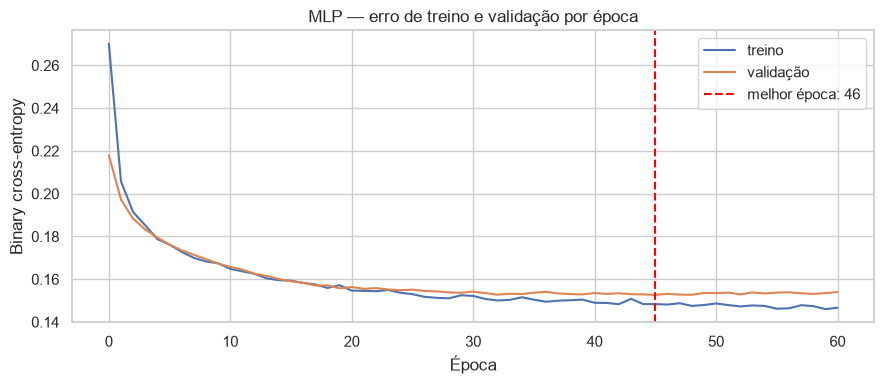

Houve início de overfitting antes da parada? True
A perda de validação atingiu o mínimo na época 46 e depois deixou de melhorar enquanto o treino continuou.


In [32]:
perda_treino = np.asarray(historico_final.history['loss'])
perda_validacao = np.asarray(historico_final.history['val_loss'])
epoca_melhor = int(np.argmin(perda_validacao) + 1)
houve_overfitting = epoca_melhor < len(perda_validacao)
plt.figure(figsize=(9, 4))
plt.plot(perda_treino, label='treino')
plt.plot(perda_validacao, label='validação')
plt.axvline(epoca_melhor - 1, color='red', linestyle='--', label=f'melhor época: {epoca_melhor}')
plt.title('MLP — erro de treino e validação por época')
plt.xlabel('Época'); plt.ylabel('Binary cross-entropy'); plt.legend(); plt.tight_layout(); plt.show()
print('Houve início de overfitting antes da parada?', houve_overfitting)
if houve_overfitting:
    print('A perda de validação atingiu o mínimo na época', epoca_melhor,
          'e depois deixou de melhorar enquanto o treino continuou.')
else:
    print('Não foi observado aumento persistente da perda de validação antes da parada.')

## 5. Árvore de decisão: treinamento, poda e avaliação

### 5.1 Árvore sem poda

Profundidade: 38 | Folhas: 2279
E_in árvore pura: 0.0031
E_out será calculado somente depois da escolha do modelo.


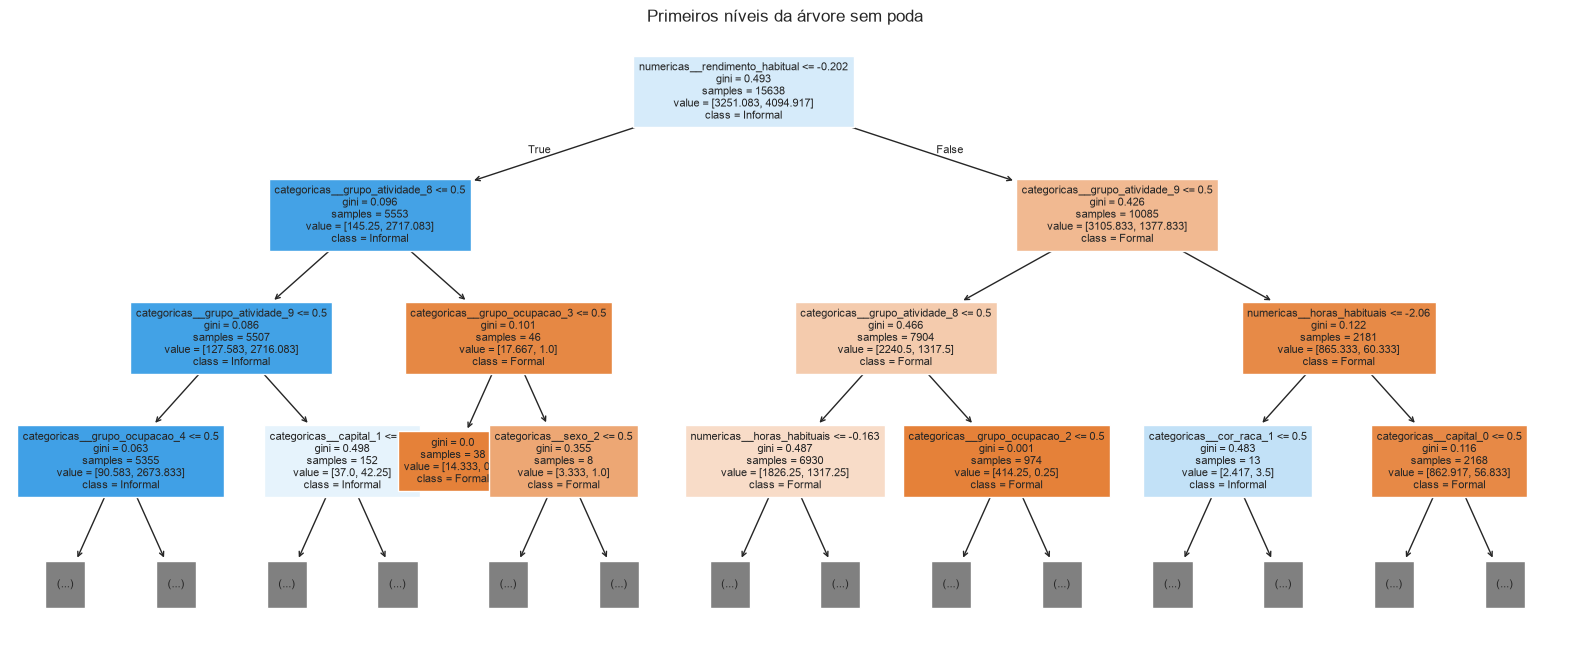

In [19]:
arvore_pura = DecisionTreeClassifier(random_state=RANDOM_STATE)
arvore_pura.fit(X_train_processado, y_train, sample_weight=pesos_train)
pred_arvore_pura_train = arvore_pura.predict(X_train_processado)
E_in_arvore_pura = 1 - accuracy_score(y_train, pred_arvore_pura_train, sample_weight=pesos_train)
print('Profundidade:', arvore_pura.get_depth(), '| Folhas:', arvore_pura.get_n_leaves())
print(f'E_in árvore pura: {E_in_arvore_pura:.4f}')
print('E_out será calculado somente depois da escolha do modelo.')
plt.figure(figsize=(20, 8))
plot_tree(arvore_pura, feature_names=nomes_atributos, class_names=['Formal', 'Informal'],
          filled=True, max_depth=3, fontsize=8)
plt.title('Primeiros níveis da árvore sem poda'); plt.show()

### 5.2 Regularização por Minimal Cost-Complexity


In [25]:
caminho = arvore_pura.cost_complexity_pruning_path(
    X_train_processado, y_train, sample_weight=pesos_train)
alphas = np.unique(caminho.ccp_alphas[:-1])
if len(alphas) > 10:
    alphas = np.unique(np.quantile(alphas, np.linspace(0, 1, 10)))
cv_arvore = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
resultados_poda = []
for alpha in alphas:
    scores = []
    for idx_tr, idx_val in cv_arvore.split(X_train_processado, y_train, grupos_train):
        candidata = DecisionTreeClassifier(random_state=RANDOM_STATE, ccp_alpha=float(alpha))
        candidata.fit(X_train_processado[idx_tr], y_train.iloc[idx_tr],
                      sample_weight=pesos_train.iloc[idx_tr])
        pred_val = candidata.predict(X_train_processado[idx_val])
        scores.append(f1_score(y_train.iloc[idx_val], pred_val,
                               sample_weight=pesos_train.iloc[idx_val]))
    resultados_poda.append({'ccp_alpha': alpha, 'f1_ponderado_cv': np.mean(scores),
                            'desvio_cv': np.std(scores)})
resultados_poda = pd.DataFrame(resultados_poda).sort_values('f1_ponderado_cv', ascending=False)
melhor_alpha = float(resultados_poda.iloc[0]['ccp_alpha'])
display(resultados_poda); print('Melhor alpha:', melhor_alpha)

,ccp_alpha,f1_ponderado_cv,desvio_cv
8,0.000198,0.853077,0.008115
7,0.000131,0.848877,0.006901
6,0.000099,0.844041,0.006748
5,0.000079,0.840705,0.006198
4,0.000063,0.838955,0.005072
3,0.000046,0.836253,0.004231
1,0.000020,0.833985,0.005153
0,0.000000,0.833877,0.004971
2,0.000033,0.833873,0.005534
9,0.018618,0.789259,0.010940


Melhor alpha: 0.00019822957454459418


Profundidade: 19 | Folhas: 74
E_in árvore podada: 0.1224
E_out será calculado somente na fase final.


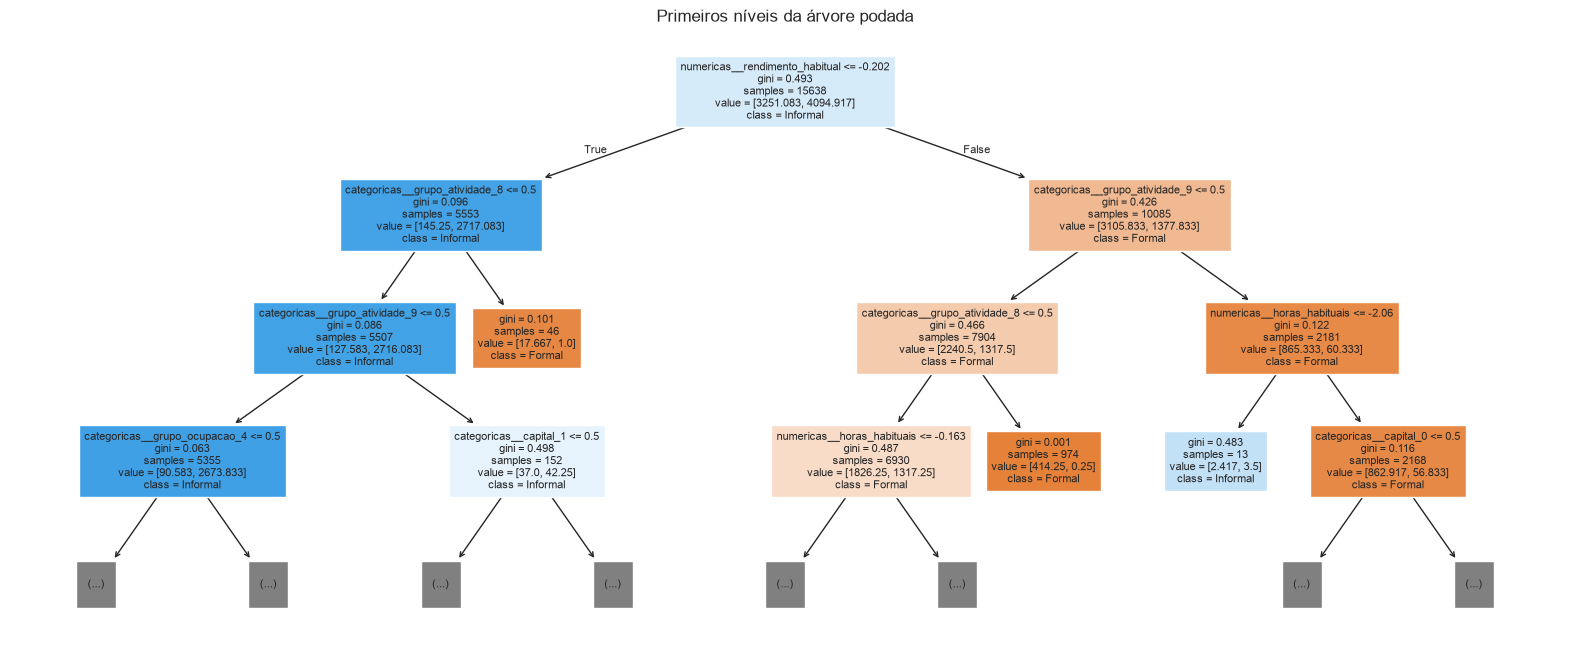

In [24]:
arvore_podada = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    ccp_alpha=melhor_alpha
)

arvore_podada.fit(
    X_train_processado,
    y_train,
    sample_weight=pesos_train
)

pred_arvore_train = arvore_podada.predict(
    X_train_processado
)

E_in_arvore_podada = 1 - accuracy_score(
    y_train,
    pred_arvore_train,
    sample_weight=pesos_train
)

print(
    "Profundidade:",
    arvore_podada.get_depth(),
    "| Folhas:",
    arvore_podada.get_n_leaves()
)

print(
    f"E_in árvore podada: "
    f"{E_in_arvore_podada:.4f}"
)

print(
    "E_out será calculado somente na fase final."
)

plt.figure(figsize=(20, 8))

plot_tree(
    arvore_podada,
    feature_names=nomes_atributos,
    class_names=["Formal", "Informal"],
    filled=True,
    max_depth=3,
    fontsize=8
)

plt.title(
    "Primeiros níveis da árvore podada"
)

plt.show()

### 5.3 Random Forest

In [26]:
floresta = RandomForestClassifier(
    n_estimators=500, max_features='sqrt', min_samples_leaf=3,
    random_state=RANDOM_STATE, n_jobs=-1)
floresta.fit(X_train_processado, y_train, sample_weight=pesos_train)
pred_rf_train = floresta.predict(X_train_processado)
E_in_rf = 1 - accuracy_score(y_train, pred_rf_train, sample_weight=pesos_train)
print(f'E_in Random Forest: {E_in_rf:.4f}')
print('E_out será calculado somente na fase final.')
importancias = pd.Series(floresta.feature_importances_, index=nomes_atributos).sort_values(ascending=False)
display(importancias.head(20).to_frame('importancia'))

E_in Random Forest: 0.0678
E_out será calculado somente na fase final.


,importancia
numericas__rendimento_habitual,0.346530
numericas__horas_habituais,0.105058
categoricas__grupo_atividade_9,0.085946
categoricas__grupo_atividade_8,0.050958
numericas__idade,0.050492
categoricas__nivel_instrucao_7,0.037423
categoricas__grupo_atividade_1,0.031109
categoricas__nivel_instrucao_2,0.024810
categoricas__grupo_ocupacao_6,0.020246
categoricas__grupo_ocupacao_4,0.017317


## 6. Escolha do modelo sem consultar o teste



In [27]:
cv_selecao = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
f1_rf_folds = []
for idx_tr, idx_val in cv_selecao.split(X_train_processado, y_train, grupos_train):
    rf_cv = RandomForestClassifier(n_estimators=200, max_features='sqrt', min_samples_leaf=3,
                                   random_state=RANDOM_STATE, n_jobs=-1)
    rf_cv.fit(X_train_processado[idx_tr], y_train.iloc[idx_tr], sample_weight=pesos_train.iloc[idx_tr])
    pred_val = rf_cv.predict(X_train_processado[idx_val])
    f1_rf_folds.append(f1_score(y_train.iloc[idx_val], pred_val,
                                sample_weight=pesos_train.iloc[idx_val]))

selecao_validacao = pd.DataFrame({
    'modelo': ['MLP com L2', 'Árvore podada', 'Random Forest'],
    'f1_validacao_ponderado': [
        float(resultados_l2.iloc[0]['f1_ponderado_cv']),
        float(resultados_poda.iloc[0]['f1_ponderado_cv']),
        float(np.mean(f1_rf_folds)),
    ]
}).set_index('modelo').sort_values('f1_validacao_ponderado', ascending=False)
modelo_escolhido_validacao = selecao_validacao.index[0]
display(selecao_validacao.style.format('{:.4f}'))
print('Modelo escolhido sem consultar o teste:', modelo_escolhido_validacao)

,f1_validacao_ponderado
modelo,
Random Forest,0.8687
MLP com L2,0.8618
Árvore podada,0.8531


Modelo escolhido sem consultar o teste: Random Forest


## 7. Avaliação final no teste e conclusão

In [28]:
X_test_processado = preprocessador.transform(X_test)
assert np.isfinite(X_test_processado).all()
pred_baseline = baseline.predict(X_test_processado)
prob_mlp = modelo_mlp.predict(X_test_processado, verbose=0).ravel()
pred_mlp = (prob_mlp >= 0.5).astype(int)
pred_arvore_pura = arvore_pura.predict(X_test_processado)
pred_arvore = arvore_podada.predict(X_test_processado)
pred_rf = floresta.predict(X_test_processado)

E_out_mlp = log_loss(y_test, prob_mlp, sample_weight=pesos_test)
E_out_arvore_pura = 1 - accuracy_score(y_test, pred_arvore_pura, sample_weight=pesos_test)
E_out_arvore_podada = 1 - accuracy_score(y_test, pred_arvore, sample_weight=pesos_test)
E_out_rf = 1 - accuracy_score(y_test, pred_rf, sample_weight=pesos_test)

erros_generalizacao = pd.DataFrame({
    'modelo': ['MLP com L2', 'Árvore pura', 'Árvore podada', 'Random Forest'],
    'E_in': [E_in_mlp, E_in_arvore_pura, E_in_arvore_podada, E_in_rf],
    'E_out': [E_out_mlp, E_out_arvore_pura, E_out_arvore_podada, E_out_rf],
}).set_index('modelo')
erros_generalizacao['gap'] = erros_generalizacao['E_out'] - erros_generalizacao['E_in']
display(erros_generalizacao.style.format('{:.4f}'))

print('MLP — métricas finais ponderadas')
print(classification_report(y_test, pred_mlp, sample_weight=pesos_test, digits=4))
print('Árvore podada — métricas finais ponderadas')
print(classification_report(y_test, pred_arvore, sample_weight=pesos_test, digits=4))
print('Random Forest — métricas finais ponderadas')
print(classification_report(y_test, pred_rf, sample_weight=pesos_test, digits=4))

,E_in,E_out,gap
modelo,,,
MLP com L2,0.2951,0.3539,0.0588
Árvore pura,0.0031,0.1977,0.1946
Árvore podada,0.1224,0.1562,0.0338
Random Forest,0.0678,0.1517,0.0839


MLP — métricas finais ponderadas
              precision    recall  f1-score   support

           0     0.7921    0.8675    0.8281 817.6666666666678
           1     0.8828    0.8143    0.8472 1002.3333333333401

    accuracy                         0.8382 1820.0000000000077
   macro avg     0.8375    0.8409    0.8376 1820.0000000000077
weighted avg     0.8421    0.8382    0.8386 1820.0000000000077

Árvore podada — métricas finais ponderadas
              precision    recall  f1-score   support

           0     0.8028    0.8649    0.8327 817.6666666666678
           1     0.8823    0.8267    0.8536 1002.3333333333401

    accuracy                         0.8438 1820.0000000000077
   macro avg     0.8425    0.8458    0.8431 1820.0000000000077
weighted avg     0.8466    0.8438    0.8442 1820.0000000000077

Random Forest — métricas finais ponderadas
              precision    recall  f1-score   support

           0     0.8055    0.8731    0.8380 817.6666666666678
           1     0.888

In [29]:
def metricas(nome, real, predito, pesos_avaliacao):
    return {
        'modelo': nome,
        'acuracia_entrevistas': accuracy_score(real, predito),
        'f1_macro_entrevistas': f1_score(real, predito, average='macro'),
        'acuracia_por_pessoa': accuracy_score(real, predito, sample_weight=pesos_avaliacao),
        'precisao_informal_por_pessoa': precision_score(real, predito, sample_weight=pesos_avaliacao, zero_division=0),
        'recall_informal_por_pessoa': recall_score(real, predito, sample_weight=pesos_avaliacao, zero_division=0),
        'f1_informal_por_pessoa': f1_score(real, predito, sample_weight=pesos_avaliacao, zero_division=0),
        'f1_macro_por_pessoa': f1_score(real, predito, average='macro', sample_weight=pesos_avaliacao),
    }
comparacao = pd.DataFrame([
    metricas('Baseline', y_test, pred_baseline, pesos_test),
    metricas('MLP com L2', y_test, pred_mlp, pesos_test),
    metricas('Árvore pura', y_test, pred_arvore_pura, pesos_test),
    metricas('Árvore podada', y_test, pred_arvore, pesos_test),
    metricas('Random Forest', y_test, pred_rf, pesos_test),
]).set_index('modelo').sort_values('f1_macro_por_pessoa', ascending=False)
display(comparacao.style.format('{:.4f}'))
print('Modelo pré-selecionado por validação:', modelo_escolhido_validacao)
print('O teste é reportado para avaliação final, não para mudar essa escolha.')

,acuracia_entrevistas,f1_macro_entrevistas,acuracia_por_pessoa,precisao_informal_por_pessoa,recall_informal_por_pessoa,f1_informal_por_pessoa,f1_macro_por_pessoa
modelo,,,,,,,
Random Forest,0.8471,0.8471,0.8483,0.8889,0.8281,0.8574,0.8477
Árvore podada,0.8428,0.8428,0.8438,0.8823,0.8267,0.8536,0.8431
MLP com L2,0.8369,0.8369,0.8382,0.8828,0.8143,0.8472,0.8376
Árvore pura,0.7988,0.7987,0.8023,0.8275,0.8099,0.8186,0.8007
Baseline,0.5210,0.3425,0.5507,0.5507,1.0000,0.7103,0.3551


Modelo pré-selecionado por validação: Random Forest
O teste é reportado para avaliação final, não para mudar essa escolha.


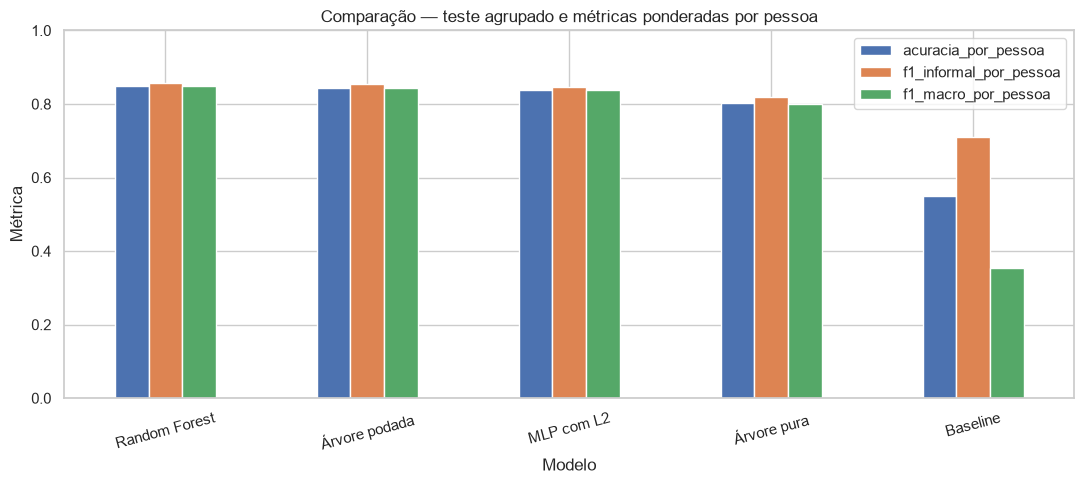

In [30]:
ax = comparacao[['acuracia_por_pessoa', 'f1_informal_por_pessoa',
                 'f1_macro_por_pessoa']].plot.bar(figsize=(11, 5), ylim=(0, 1))
ax.set_title('Comparação — teste agrupado e métricas ponderadas por pessoa')
ax.set_ylabel('Métrica'); ax.set_xlabel('Modelo')
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

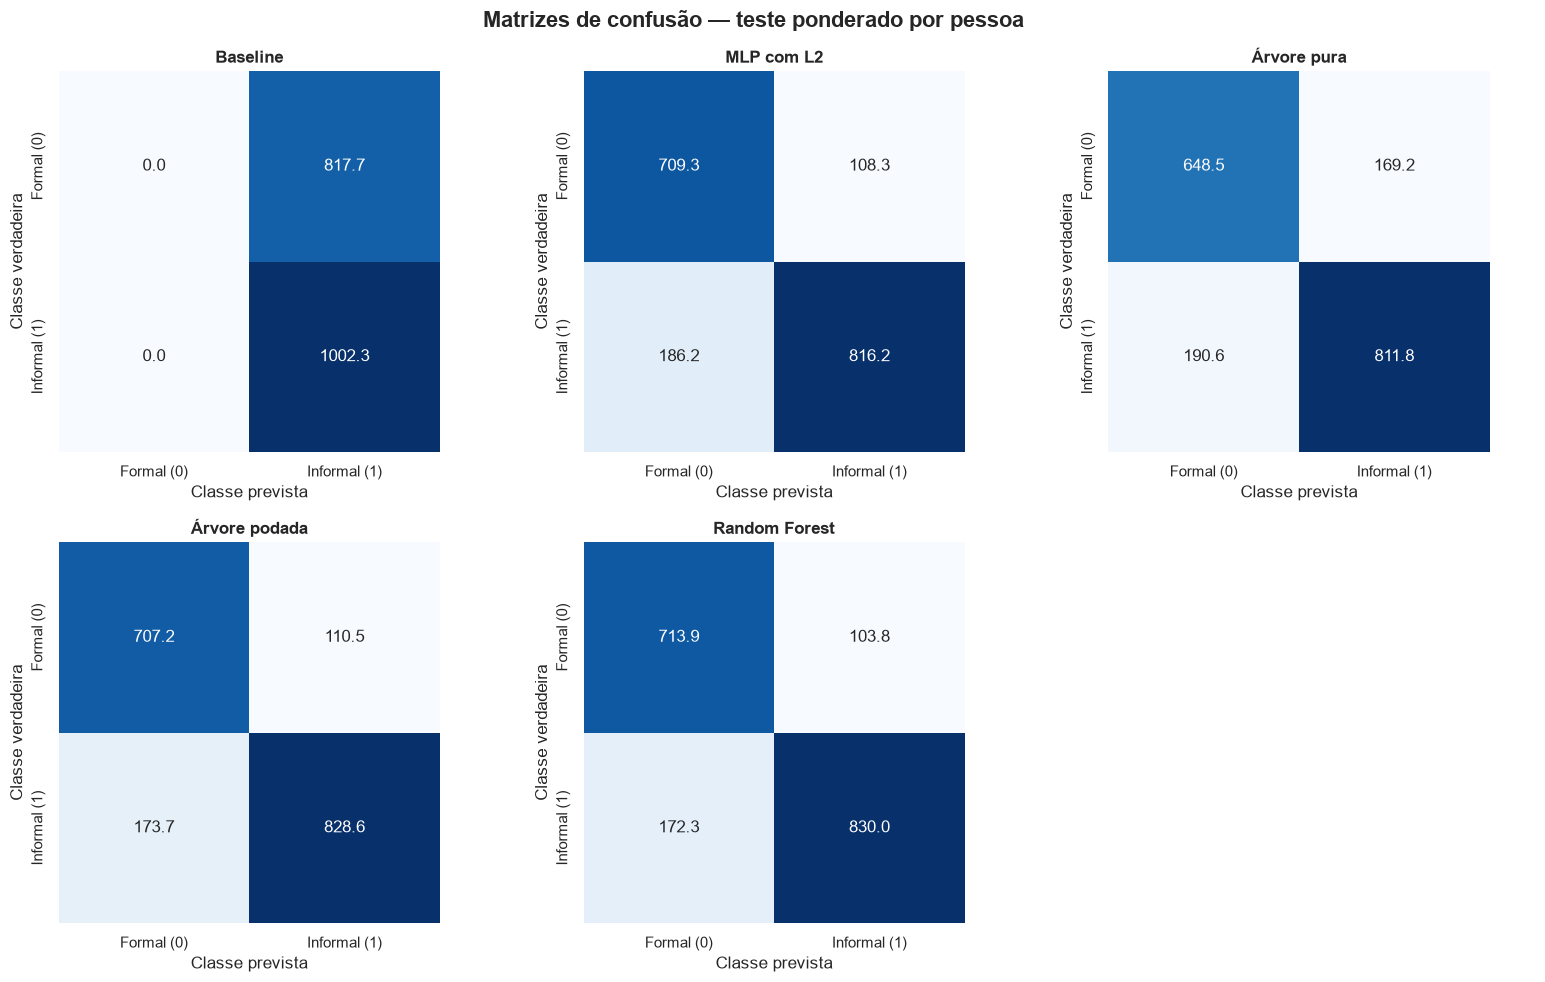

In [34]:
modelos_predicoes = {
    'Baseline': pred_baseline,
    'MLP com L2': pred_mlp,
    'Árvore pura': pred_arvore_pura,
    'Árvore podada': pred_arvore,
    'Random Forest': pred_rf
}

nomes_classes = ['Formal (0)', 'Informal (1)']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for eixo, (nome_modelo, previsoes) in zip(axes, modelos_predicoes.items()):
    matriz = confusion_matrix(y_test, previsoes, labels=[0, 1], sample_weight=pesos_test)

    sns.heatmap(matriz, annot=True, fmt='.1f', cmap='Blues', cbar=False, square=True,
                xticklabels=nomes_classes, yticklabels=nomes_classes, ax=eixo)

    eixo.set_title(nome_modelo, fontweight='bold')
    eixo.set_xlabel('Classe prevista')
    eixo.set_ylabel('Classe verdadeira')

axes[-1].axis('off')
plt.suptitle('Matrizes de confusão — teste ponderado por pessoa', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

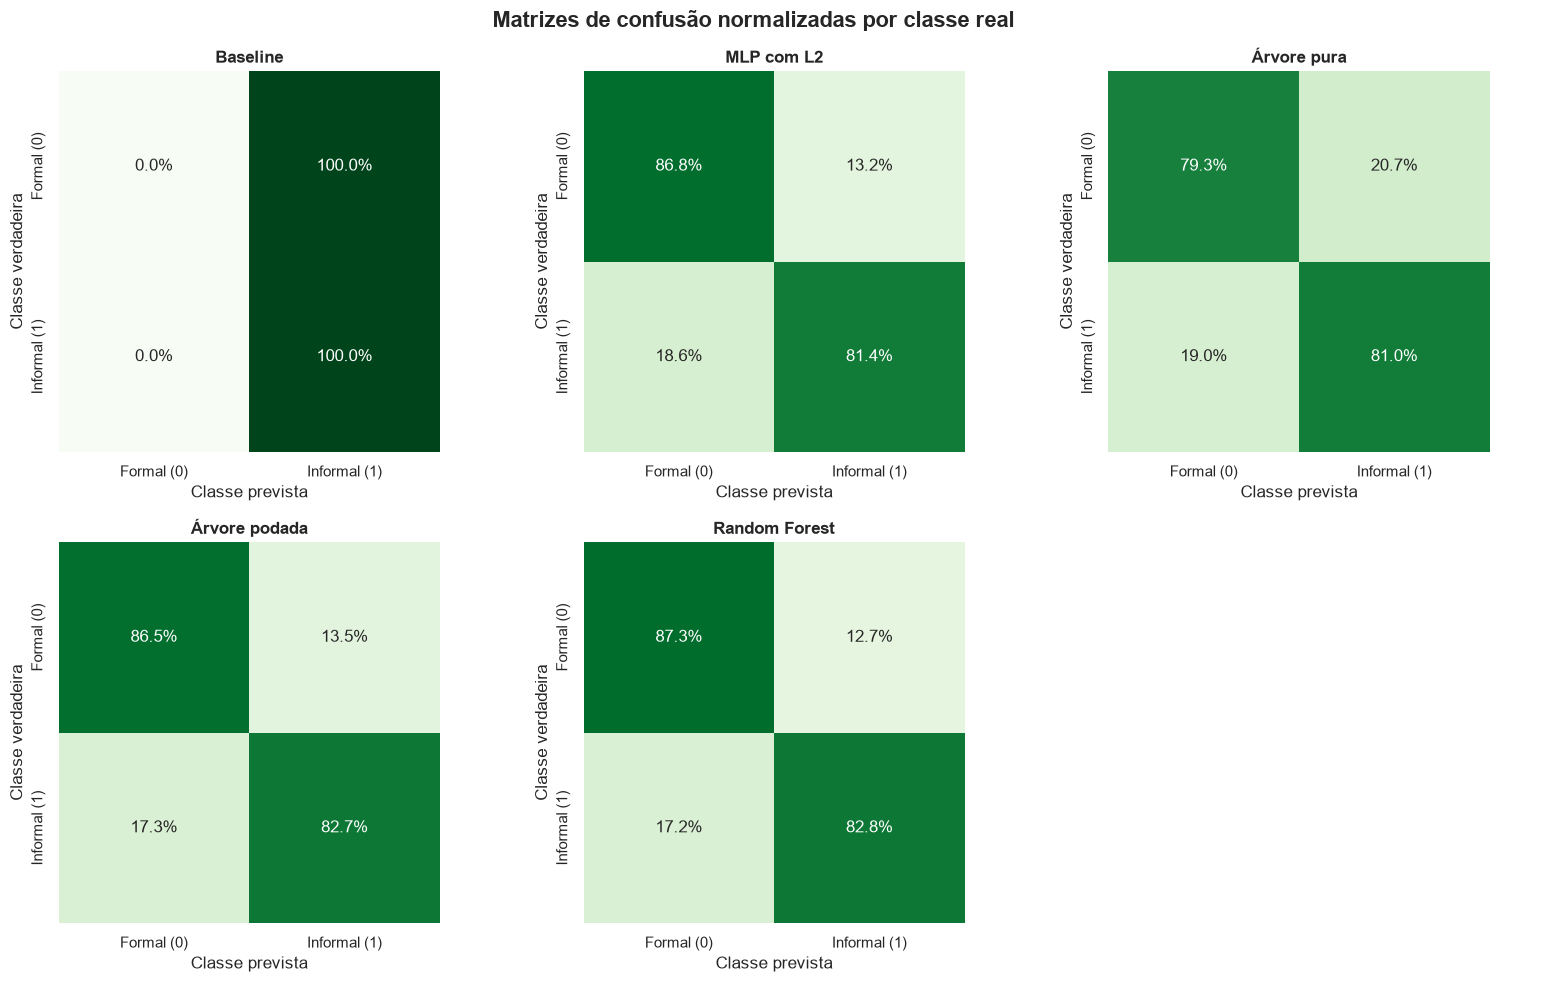

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for eixo, (nome_modelo, previsoes) in zip(axes, modelos_predicoes.items()):
    matriz_normalizada = confusion_matrix(y_test, previsoes, labels=[0, 1],
                                          sample_weight=pesos_test, normalize='true')

    sns.heatmap(matriz_normalizada, annot=True, fmt='.1%', cmap='Greens',
                vmin=0, vmax=1, cbar=False, square=True,
                xticklabels=nomes_classes, yticklabels=nomes_classes, ax=eixo)

    eixo.set_title(nome_modelo, fontweight='bold')
    eixo.set_xlabel('Classe prevista'); eixo.set_ylabel('Classe verdadeira')

axes[-1].axis('off')
plt.suptitle('Matrizes de confusão normalizadas por classe real', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

### Conclusão alinhada aos requisitos

- A base governamental representa um problema social relevante e exigiu engenharia de dados.
- `X`, `y`, `N` e `p` são identificados; pesos, IDs, tempo e definidores do alvo não entram como atributos.
- O teste permaneceu fora da imputação, padronização, validação, regularização e escolha de modelos.
- A arquitetura da MLP respeita a Regra de Ouro via dimensão VC e inclui bias; uma camada oculta é justificada pelo Teorema da Aproximação Universal.
- Batch, épocas, L2, dropout e early stopping são justificados e escolhidos sem teste.
- `E_in`, `E_out`, gap e curva de perdas permitem diagnosticar overfitting na MLP e nas árvores.
- A poda usa Minimal Cost-Complexity e validação cruzada agrupada.
- O modelo final é escolhido pelo desempenho de validação; o teste serve somente para a avaliação final.
- Todas as entrevistas são mantidas, mas cada pessoa possui peso total 1; pessoas e domicílios não atravessam conjuntos.
- O estudo mede associações e capacidade de classificação, não causalidade nem previsão do próximo trimestre.